# ☕ Coffee Sales Analysis & Prediction

This project analyzes coffee sales from a vending machine over a 7-month period (March-August 2024). The goal is to better understand sales trends based on coffee types, monthly variation, pricing, and purchase method (cash vs. card).

Additionally, we use Machine Learning models to predict sales revenue and understand feature importances.

**Key Objectives:**
1. **Data Preprocessing & Cleaning:** Handle missing values and extract useful time-based features.
2. **Exploratory Data Analysis (EDA):** Visualize sales trends, popular coffee types, and peak hours.
3. **Machine Learning:** Train Regression models to predict transaction revenue based on contextual features.

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set visualization style
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

## 1. Data Loading & Inspection
First, let's load the dataset and perform an initial inspection to understand its structure.

In [1]:
# Loading and viewing the data
df = pd.read_csv('Coffee_Sales_Analysis.csv')

# Display basic info and first few rows
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1133 non-null   object 
 1   datetime     1133 non-null   object 
 2   cash_type    1133 non-null   object 
 3   card         1044 non-null   object 
 4   money        1133 non-null   float64
 5   coffee_name  1133 non-null   object 
dtypes: float64(1), object(5)
memory usage: 53.2+ KB


,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


## 2. Data Preprocessing & Feature Engineering
We observe missing values in the `card` column. Since these correspond to cash transactions, we will fill them accordingly. We will also convert date/time columns to proper datetime objects and extract useful temporal features (month, day of week, hour).

In [1]:
# 1. Handle missing values: Fill nulls in 'card' with 'cash_transaction'
df['card'] = df['card'].fillna('cash_transaction')

# 2. Convert to datetime formats
df['date'] = pd.to_datetime(df['date'])
df['datetime'] = pd.to_datetime(df['datetime'])

# 3. Extract temporal features
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['day_of_week'] = df['date'].dt.day_name()
df['hour'] = df['datetime'].dt.hour

# Display the transformed dataset
df.head()

,date,datetime,cash_type,card,money,coffee_name,month,year,day_of_week,hour
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,3,2024,Friday,10
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,3,2024,Friday,12
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,3,2024,Friday,12
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,3,2024,Friday,13
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,3,2024,Friday,13


## 3. Exploratory Data Analysis (EDA)
In this section, we'll explore sales distributions, revenue generated by different coffee types, and time-based sales patterns.

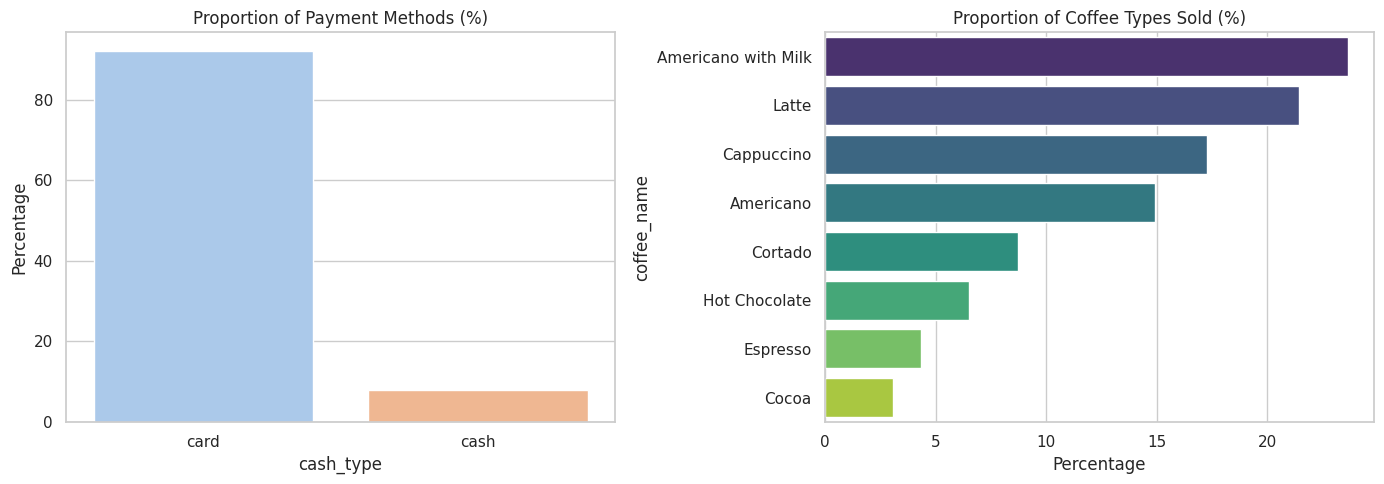

In [1]:
# Distribution of Payment Methods & Coffee Types
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cash_split = df['cash_type'].value_counts(normalize=True) * 100
sns.barplot(x=cash_split.index, y=cash_split.values, ax=axes[0], palette='pastel')
axes[0].set_title('Proportion of Payment Methods (%)')
axes[0].set_ylabel('Percentage')

# Proportion of Coffee Types
coffee_split = df['coffee_name'].value_counts(normalize=True) * 100
sns.barplot(x=coffee_split.values, y=coffee_split.index, ax=axes[1], palette='viridis')
axes[1].set_title('Proportion of Coffee Types Sold (%)')
axes[1].set_xlabel('Percentage')

plt.tight_layout()
plt.show()

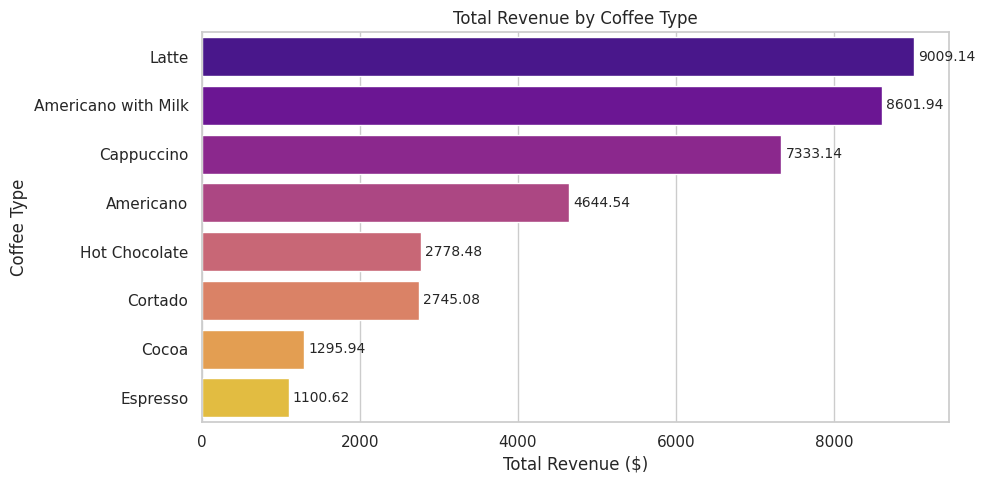

In [1]:
# Overall revenue by products
revenue = df.groupby('coffee_name')['money'].sum().reset_index().sort_values(by='money', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=revenue, x='money', y='coffee_name', palette='plasma')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.xlabel('Total Revenue ($)')
plt.ylabel('Coffee Type')
plt.title('Total Revenue by Coffee Type')
plt.tight_layout()
plt.show()

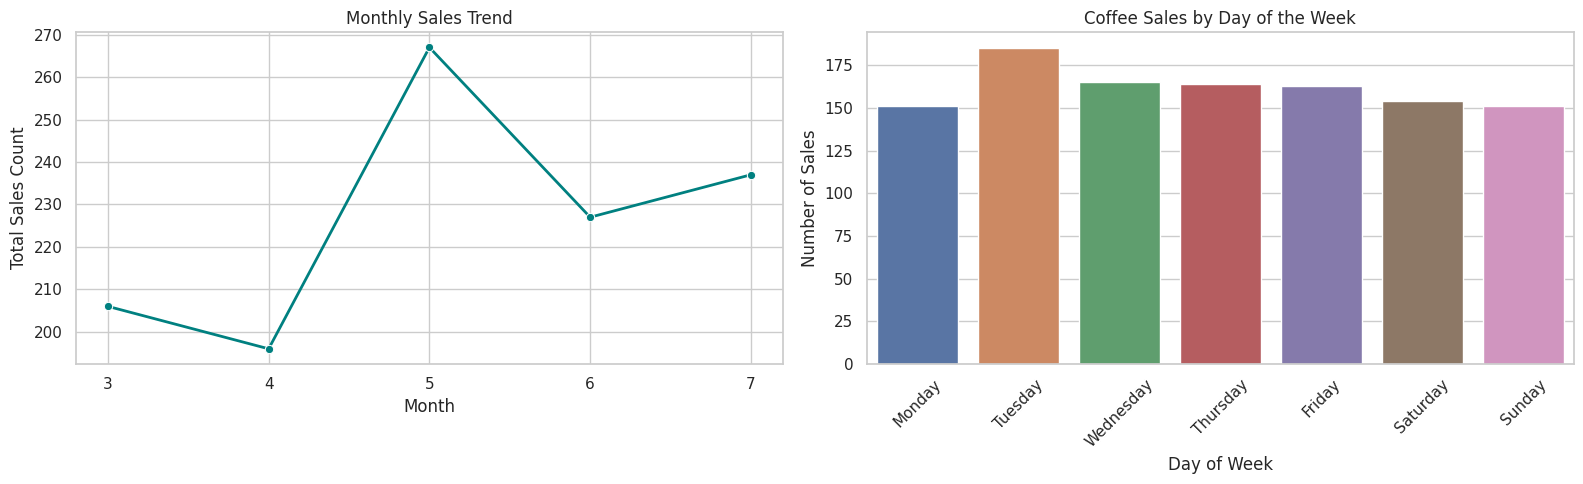

In [1]:
# Visualising Monthly and Weekly Sales Trends
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly Sales
monthly_sales = df.groupby('month').size().reset_index(name='count')
sns.lineplot(data=monthly_sales, x='month', y='count', marker='o', ax=axes[0], color='teal', linewidth=2)
axes[0].set_title('Monthly Sales Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Sales Count')
axes[0].set_xticks(monthly_sales['month'])

# Weekly Sales
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = df['day_of_week'].value_counts().reindex(weekday_order).reset_index()
weekday_sales.columns = ['day_of_week', 'count']

sns.barplot(data=weekday_sales, x='day_of_week', y='count', palette='deep', ax=axes[1])
axes[1].set_title('Coffee Sales by Day of the Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Sales')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

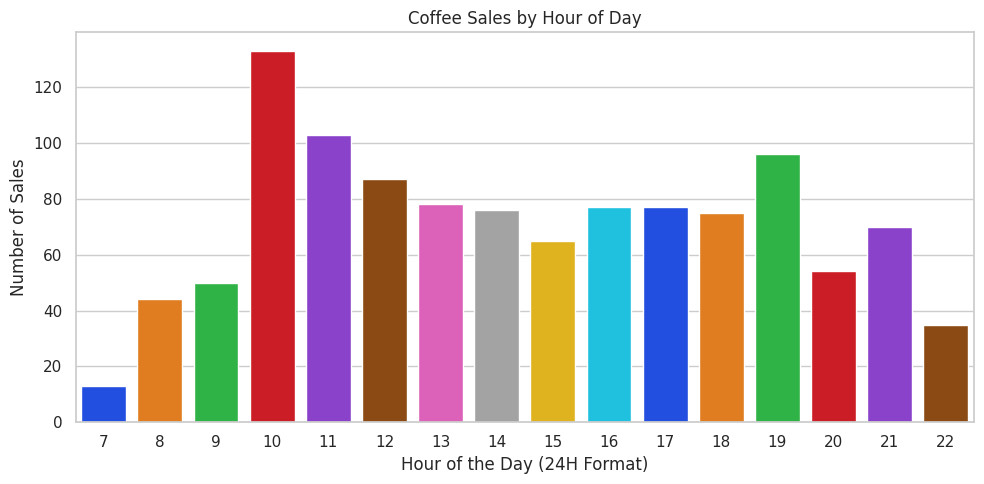

In [1]:
# Hourly Sales Distribution
hourly_sales = df.groupby('hour').size().reset_index(name='count')

plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_sales, x='hour', y='count', palette='bright')
plt.xlabel('Hour of the Day (24H Format)')
plt.ylabel('Number of Sales')
plt.title('Coffee Sales by Hour of Day')
plt.tight_layout()
plt.show()

## 4. Machine Learning Modeling
We will build regression models to predict the transaction amount (`money`) based on contextual features like coffee type, time, and payment method.

We will compare two models:
1. **Linear Regression** (Baseline model)
2. **Random Forest Regressor** (Advanced model to capture non-linear relationships)

In [1]:
# Feature Selection and Target Definition
X = df.drop(columns=['money', 'date', 'datetime'])
y = df['money']

# One-hot encoding for categorical variables
X = pd.get_dummies(X, drop_first=True)

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (906, 463)
Testing features shape: (227, 463)


In [1]:
# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print(f'Linear Regression - Mean Squared Error: {lr_mse:.4f}')
print(f'Linear Regression - R^2 Score: {lr_r2:.4f}')

Linear Regression - Mean Squared Error: 8154808699491354411008.0000
Linear Regression - R^2 Score: -438042641539482976256.0000


In [1]:
# 2. Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print(f'Random Forest - Mean Squared Error: {rf_mse:.4f}')
print(f'Random Forest - R^2 Score: {rf_r2:.4f}')

Random Forest - Mean Squared Error: 0.8870
Random Forest - R^2 Score: 0.9524


### Model Comparison & Feature Importance
Let's visualize the predictions of both models against the actual prices, and determine which features are driving the Random Forest predictions.

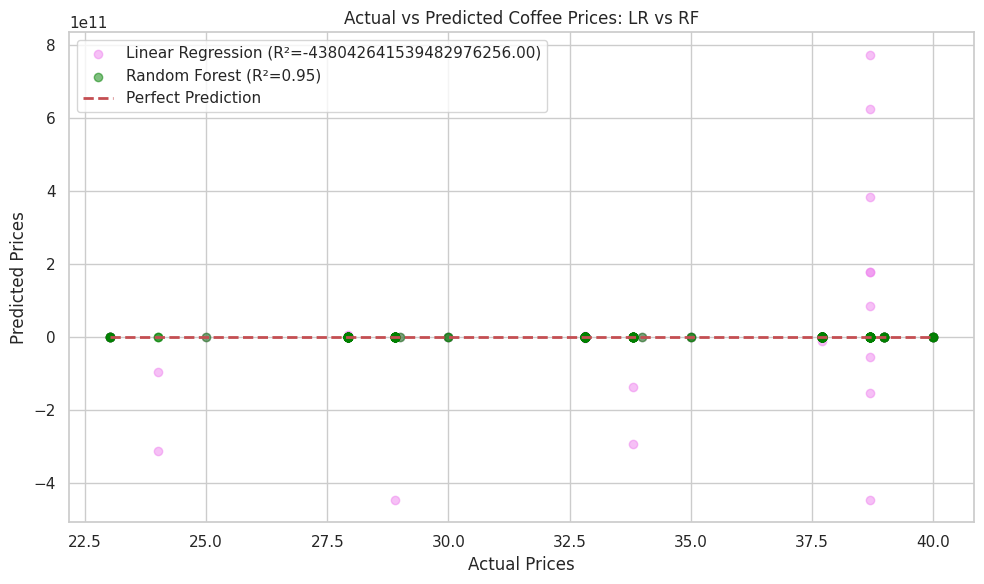

In [1]:
# Actual vs Predicted Comparison Plot
plt.figure(figsize=(10, 6))

# Scatter for Linear Regression
plt.scatter(y_test, y_pred_lr, color='violet', alpha=0.5, label=f'Linear Regression (R²={lr_r2:.2f})')

# Scatter for Random Forest
plt.scatter(y_test, y_pred_rf, color='green', alpha=0.5, label=f'Random Forest (R²={rf_r2:.2f})')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Coffee Prices: LR vs RF')
plt.legend()
plt.tight_layout()
plt.show()

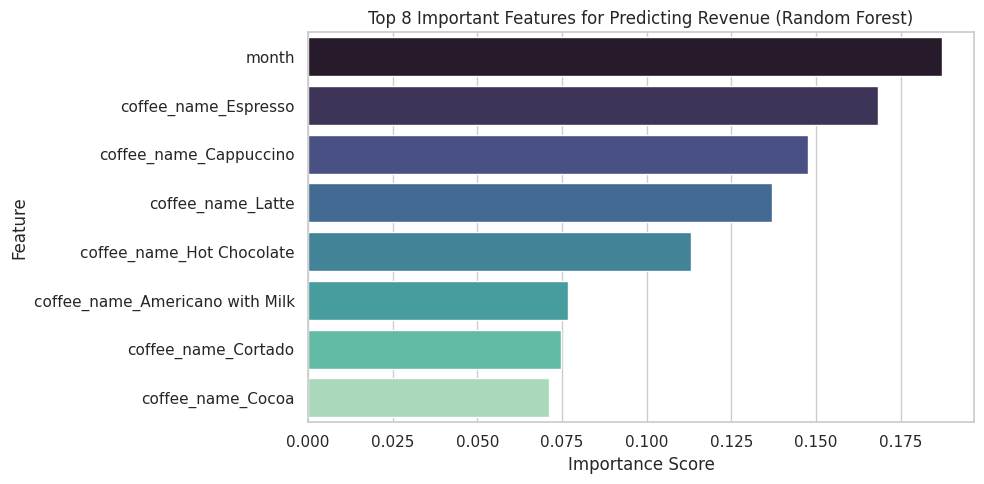

In [1]:
# Extract Feature Importances from Random Forest dynamically
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(8) # Top 8 features

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='mako')
plt.title("Top 8 Important Features for Predicting Revenue (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()